In [7]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.metrics import accuracy_score,log_loss

In [8]:
glass=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Glass_Identification\\Glass.csv")
glass

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,building_windows_float_processed
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,headlamps
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,headlamps
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,headlamps
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,headlamps


In [9]:
le=LabelEncoder()
glass['Type']=le.fit_transform(glass['Type'])
X,y=glass.drop("Type",axis=1),glass["Type"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=26,stratify=y)

In [11]:
depths=np.arange(1,7)
splits=np.arange(2,25)
leaves=np.arange(1,15)
scores=[]
for d in tqdm(depths):
    for s in splits:
        for l in leaves:
             dtc=DecisionTreeClassifier(random_state=26,min_samples_leaf=l,min_samples_split=s,max_depth=d)
    dtc.fit(X_train,y_train)
    y_pred_prob=dtc.predict_proba(X_test)
    scores.append([d,s,l,log_loss(y_test,y_pred_prob)])
df_scores=pd.DataFrame(scores,columns=["depths","split","leaves","score"])
df_scores.sort_values("score")

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 77.25it/s]


,depths,split,leaves,score
0,1,24,14,1.719655
4,5,24,14,2.403946
3,4,24,14,2.420648
2,3,24,14,2.441103
1,2,24,14,2.519059
5,6,24,14,2.884462


### Best Tree

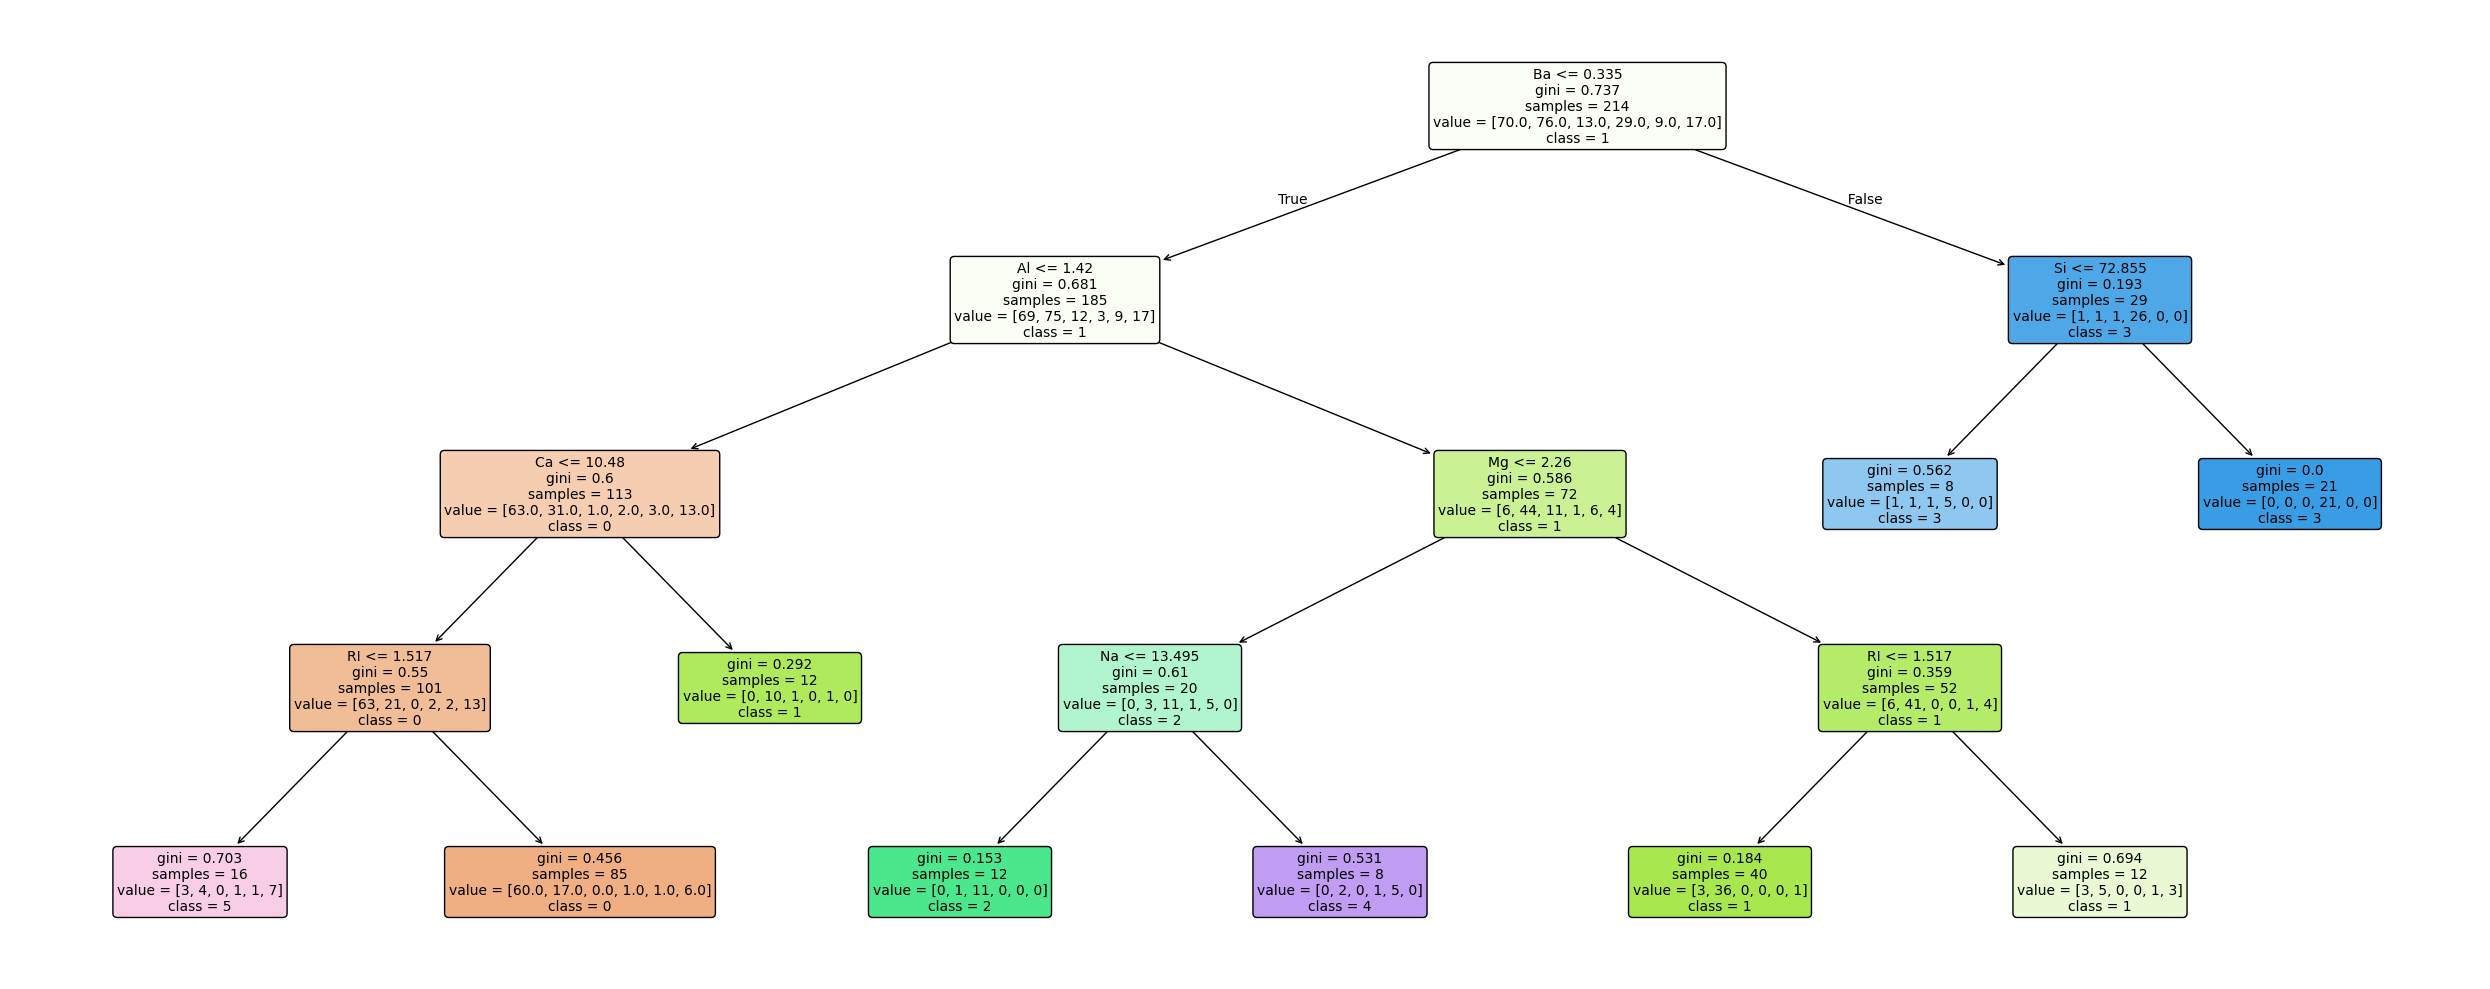

In [17]:
bm = DecisionTreeClassifier(random_state=26, min_samples_leaf=8, max_depth=4, min_samples_split=20)
bm.fit(X, y)
actual_names = [str(c) for c in bm.classes_]
plt.figure(figsize=(25, 10))
plot_tree(bm, feature_names=list(X.columns), class_names=actual_names, filled=True, fontsize=10,rounded=True)
plt.tight_layout()
plt.show()

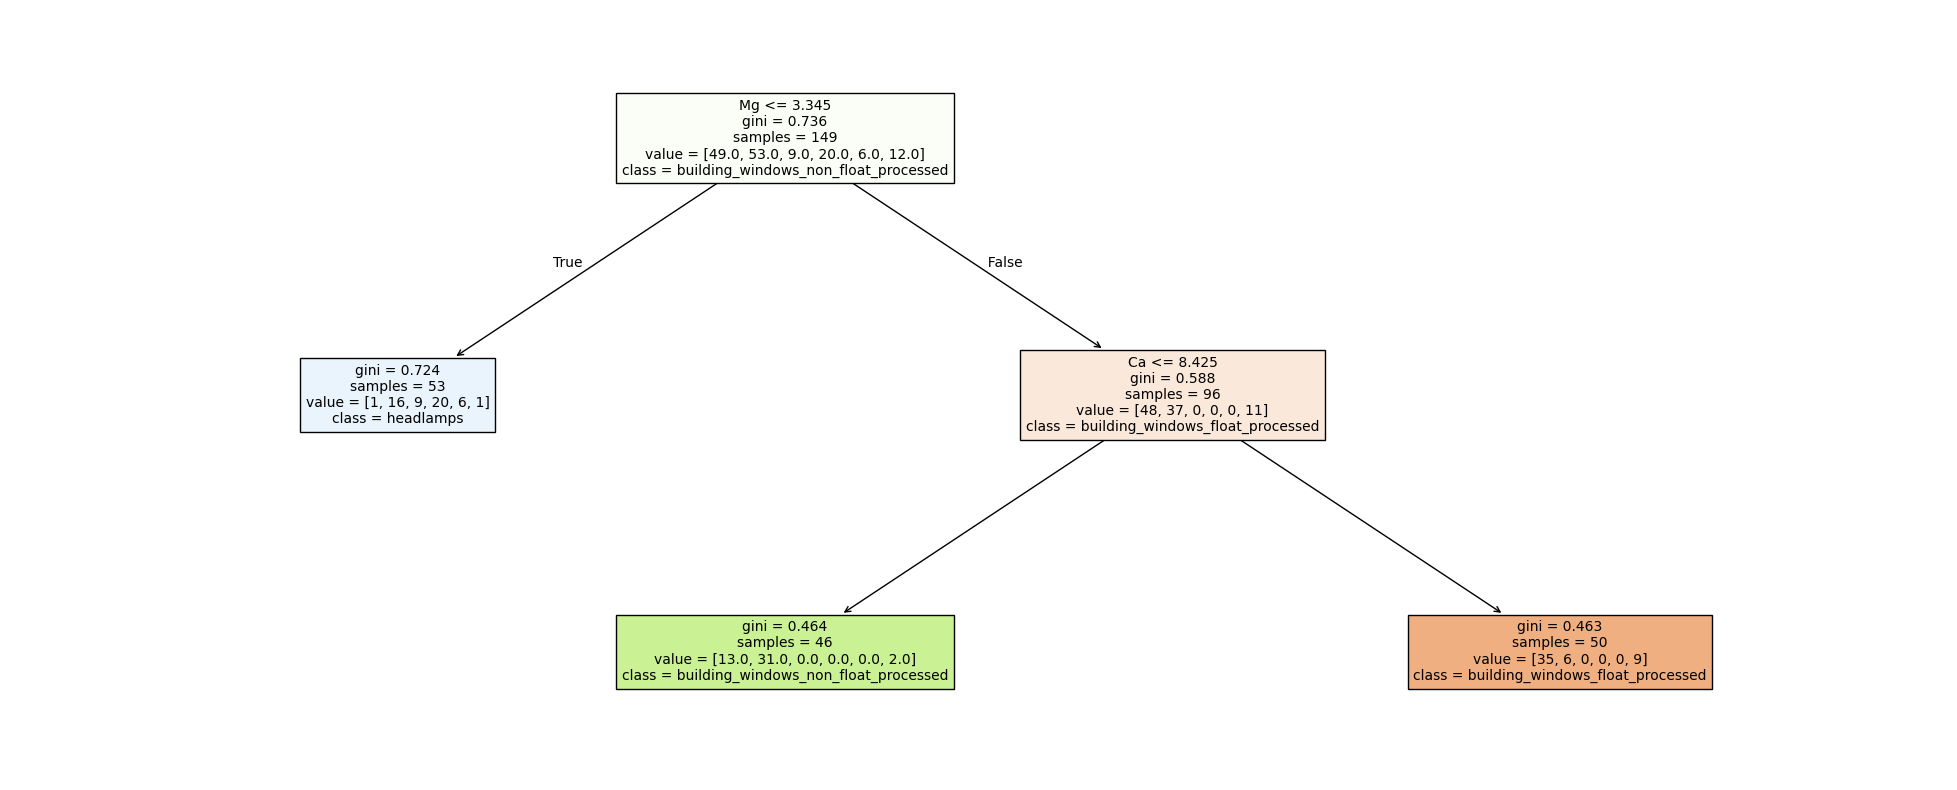

In [19]:
bm=DecisionTreeClassifier(random_state=26,min_samples_leaf=46,max_depth=None, min_samples_split=10)
bm.fit(X_train,y_train)
plt.figure(figsize=(25,10))
plot_tree(bm,feature_names=X.columns,
          class_names=["building_windows_float_processed","building_windows_non_float_processed","containers",
                       "headlamps","tableware","vehicle_windows_float_processed" ],
          filled=True,fontsize=10)
plt.show()

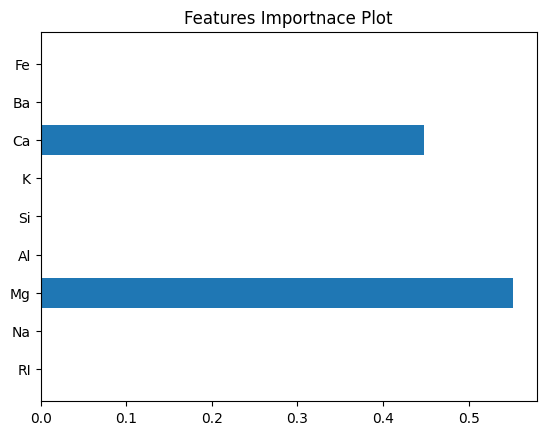

In [20]:
df_imp=pd.DataFrame({"feature":X.columns,"importance": bm.feature_importances_})
plt.barh(df_imp["feature"],df_imp["importance"])

plt.title("Features Importnace Plot")
plt.show()